## PB230


Power (kW)          3
Wind speed (m/s)    5
dtype: int64

X shape: (492, 1)
y shape: (492,)

Training data size: (369, 1)
Testing data size: (123, 1)
Training data size: (369,)
Testing data size: (123,)

Degree= 3
MSE= 270.0250095299955
R2_score= 0.8539264141973832
Degree= 4
MSE= 209.3184510784717
R2_score= 0.8867664266472862
Degree= 5
MSE= 212.4228861347375
R2_score= 0.8850870416105098
Degree= 6
MSE= 169.170104193283
R2_score= 0.9084852037478769


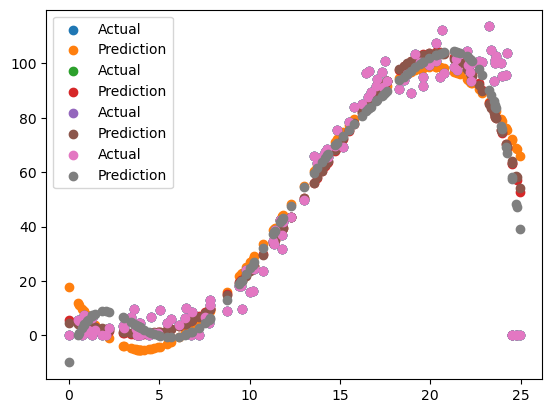

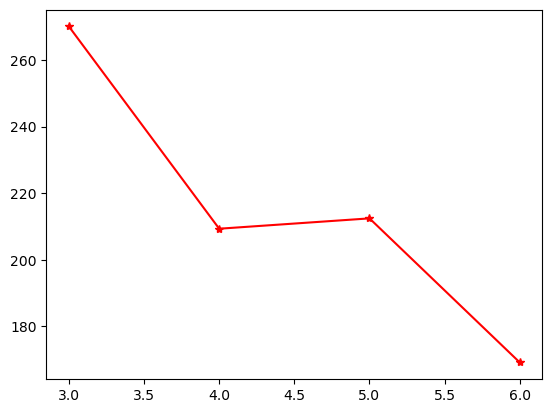

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# a) Load the windpower dataset
df = pd.read_csv('windpower.csv')
df
print()
# b) Check for missing values and remove them permanently
print(df.isnull().sum())
df.dropna(inplace=True) 
print()
# c) Split the dataset into training (75%) and testing (25%)
X = df[['Wind speed (m/s)']] 
y = df['Power (kW)']
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)
print()
# d, e, h) Train models, Predict, and Print Metrics/Coefficients
degrees = [3, 4, 5, 6]
MSE = []
for i in degrees:
    # d) Polynomial features create karna
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(X_train)
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    X_test_poly = poly.transform(X_test)
    # e) Prediction
    y_pred = lr.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    MSE.append(mse)
    R2_score = r2_score(y_test, y_pred)
    print("Degree=",i)
    print("MSE=",mse)
    print("R2_score=",R2_score)
    plt.scatter(X_test,y_test,label='Actual')
    plt.scatter(X_test,y_pred,label='Prediction')
plt.legend()
plt.show()   
print()
plt.plot(degrees,MSE,'*-r')
plt.show()
print()

# Random_Forest

#### classification algorith

In [ ]:
RANDOM FOREST

1)Read CSV file
2)Check Null Value
3)required to get dummies.
4)Define X & y
5)Split data Into train and test
6)Train Random Forest Model
7)Prediction
8)Model Evaluation
9)Assigning Confusion Matrix(CM) Values find TP,TN,FP,FN
10)Calculate Metrics: Accuracy, Error Rate, Sensitivity, Specificit

In [22]:
# 1)
import pandas as pd
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [23]:
# 2)
print(df.isnull().sum())
df.dropna(inplace=True)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
# 3) Get dummies (if any categorical columns exist)

In [24]:
# 4) 
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [25]:
# 5)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (614, 8)
Testing data size: (154, 8)
Training data size: (614,)
Testing data size: (154,)


In [26]:
# 6)
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators=100, random_state=42,max_depth=5)
rf.fit(X_train, y_train)
rf

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# 7)
y_pred = rf.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [28]:
# 8)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[83, 16],
       [20, 35]])

In [29]:
#9)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]
print("True Positives (TP):", TP)
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)



True Positives (TP): 35
True Negatives (TN): 83
False Positives (FP): 16
False Negatives (FN): 20


In [31]:
# 10)
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
print(f"Accuracy:",accuracy)
print(f"Error Rate:",error_rate)
print(f"Sensitivity:",sensitivity)
print(f"Specificity:",specificity)

Accuracy: 0.7662337662337663
Error Rate: 0.23376623376623376
Sensitivity: 0.6363636363636364
Specificity: 0.8383838383838383


### EXAMPLE

Title:1 Problem Definition: 
The goal is to predict hotel booking status using the K-Nearest Neighbors (KNN) classification algorithm.
    The dataset is preprocessed by one-hot encoding categorical features. The data is split into training and testing sets (80%-20%). 
    The model is optimized by trying different values of 'k' (1 to 20), selecting the one that gives the highest accuracy. Finally,
    the best KNN model is trained and evaluated to predict booking status effectively. 
solve using Random forest

[0.8283942108890421, 0.8250861474844935, 0.8263266712611992, 0.8231564438318401, 0.822880771881461, 0.822329427980703, 0.8245348035837353, 0.819434872501723, 0.8206753962784287, 0.8158511371467954, 0.8172294968986905, 0.816815988973122, 0.8172294968986905, 0.8150241212956582, 0.8147484493452791, 0.8151619572708477, 0.8183321847002067, 0.8155754651964162, 0.8125430737422468, 0.8141971054445211]
best_accuracy: 51
[ True  True  True ...  True  True  True]
CM= [[1367 1049]
 [ 196 4643]]
accuracy= 0.8283942108890421
arror_rate= 0.17160578911095797
sensitivity= 0.9594957635875181
specificity= 0.5658112582781457


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


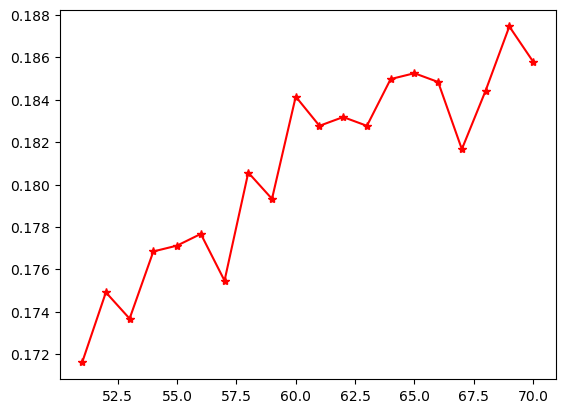

In [79]:
import pandas as pd
df=pd.read_csv('Hotel Reservations.csv')
df.isna().sum()

df.drop(columns='Booking_ID',inplace=True)

df=pd.get_dummies(df,drop_first=True)

y=df['booking_status_Not_Canceled']
x=df.drop(columns='booking_status_Not_Canceled')

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
   

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,mean_squared_error,confusion_matrix

n=range(51,71)
min=[]
mse=[]

for i in n:
    rf=RandomForestClassifier(n_estimators=i,max_depth=5,random_state=42)
    model=rf.fit(x_train,y_train)
    
    y_pred=model.predict(x_test)

    MSE=mean_squared_error(y_pred,y_test)
    mse.append(MSE)

    accuracy=accuracy_score(y_test,y_pred)
    min.append(accuracy)
print(min)

index=min.index(max(min))
n1=index+51
print("best_accuracy:",n1)
rf=RandomForestClassifier(n_estimators=n1,max_depth=5,random_state=42)
model=rf.fit(x_train,y_train)

y_pred=model.predict(x_test)
print(y_pred)

new_pred = rf.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
new_pred

cm=confusion_matrix(y_test,y_pred)
print('CM=',cm)

tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]

accuracy=(tn+tp)/(tn+tp+fn+fp)
arror_rate=(fn+fp)/(tn+tp+fn+fp)
sensitivity=tp/(tp+fn)
specificity=tn/(tn+fp)
print('accuracy=',accuracy)
print('arror_rate=',arror_rate)
print('sensitivity=',sensitivity)
print('specificity=',specificity)


import matplotlib.pyplot as plt
plt.plot(n,mse,'*-r')
plt.show()

## DECISION 

[np.float64(0.7651274982770503), np.float64(0.7651274982770503), np.float64(0.7830461750516885), np.float64(0.8137835975189525), np.float64(0.830737422467264), np.float64(0.833907649896623), np.float64(0.850999310820124), np.float64(0.8578911095796002), np.float64(0.867539627842867), np.float64(0.868090971743625), np.float64(0.8745692625775328), np.float64(0.8796691936595451), np.float64(0.8781529979324604), np.float64(0.882012405237767), np.float64(0.8784286698828394), np.float64(0.878566505858029), np.float64(0.8773259820813232), np.float64(0.8773259820813232), np.float64(0.8766368022053757), np.float64(0.8760854583046175)]
14
[ True]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


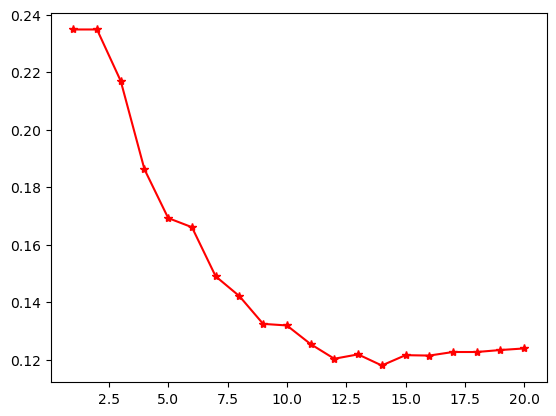

In [80]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
accu = []
MSE=[]
depth=[]
for i in range(1,21):
    model= DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=42)
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    cm = confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy = (TP+TN)/(TP+TN+FP+FN)
    mse = mean_squared_error(y_test, y_pred)
    accu.append(accuracy)
    depth.append(i)
    MSE.append(mse)

print(accu)
max_index = accu.index(max(accu))+1
print(max_index)

model= DecisionTreeClassifier(criterion='entropy', max_depth=max_index, random_state=42)
model.fit(x_train, y_train)
pred=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
print(pred)

import matplotlib.pyplot as plt
plt.plot(depth,MSE,'*-r')
plt.show()

## KNN

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([False])

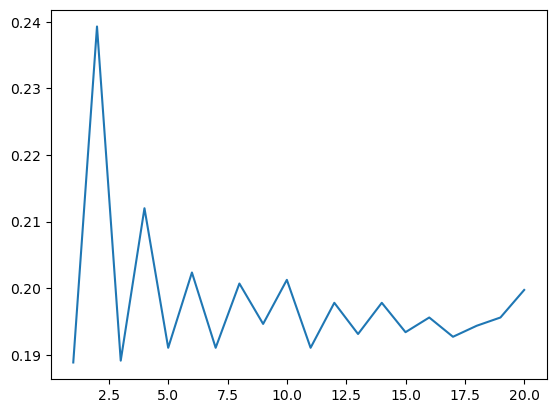

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('Hotel Reservations.csv')
df.isna().sum()
df.drop(columns=['Booking_ID'],inplace=True)
df=pd.get_dummies(df,drop_first=True)
df.head()
df.isna().sum()
y=df['booking_status_Not_Canceled']
x=df.drop(columns=['booking_status_Not_Canceled'])
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,mean_squared_error
acc=[]
mse=[]
for i in range(1,21):
    nn=KNeighborsClassifier(i)
    model=nn.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    acc.append(accuracy_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))
acc
high=max(acc)
high
plt.plot(range(1,21),mse)
nn=KNeighborsClassifier(1)
model=nn.fit(x_train,y_train)
model
y_pred=model.predict(x_test)
y_pred
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict